In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from utils import Value
from graph import draw_dot
%matplotlib inline

## Basic


In [28]:
def f(x):
    return 3 * x**2 - 4 * x + 5

In [29]:
f(3.0)

20.0

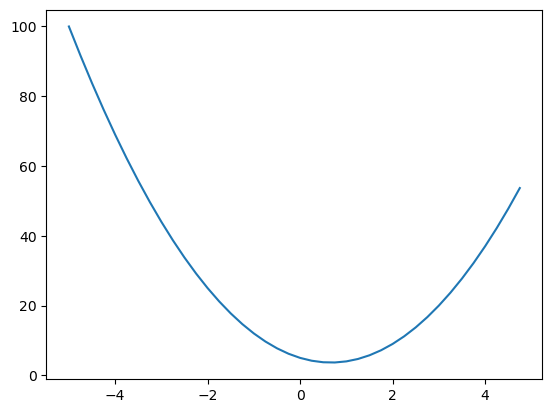

In [30]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [31]:
# the derivative h -> 0
h = 0.00000000001
x = 2
(f(x + h) - f(x)) / h

8.000000661922968

In [32]:
# les get more complex
# this time there would be more variables
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [ ]:
h = 0.0000000001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a * b + c
c += h # for d wrt to c, 1
#b += h # for d wrt to a, 2
#a += h # for d wrt to b, -3
d2 = a * b + c

print("d1", d1)
print("d2", d2)


print("slope", (d2 - d1) / h)

d1 4.0
d2 4.0000000001
slope 1.000000082740371


MANUAL BACKPROP

> Jis ke respect main derivative nikalna hai usko thoda h->0 increase kardo or diff/h kardo.

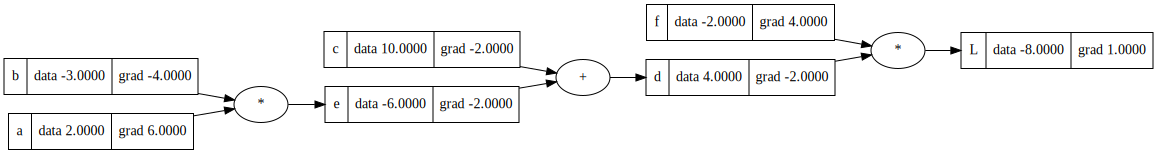

In [22]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
f = Value(-2.0, label="f")
L = d * f
L.label = "L"
## The derivative of L wrt to L is 1. so mark it
L.grad = 1
d.grad = -2
f.grad = 4
c.grad = -2
e.grad = -2
b.grad = -4
a.grad = 6
draw_dot(L)

In [23]:
a.data += 0.01 * a.grad 
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f

print(L.data)

-7.286496


Lets find dl/dd

l = d * f
dl/dd = f

> with this we will programmaticaly find grad for each node 

d.grad = -2.0
f.grad = 4.0

for are other the grad will be from the final to first

as d = c + e

dl/dc = dl/dd * dd/dc
dl/dc = f * 1
dl/dc = f

dl/de = dl/dd * dd/de
dl/de = f * 1
dl/de = f

> so we can see that on + the derivative is equal 

In [12]:
def lol():
    h = 0.0000001
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f
    L.label = "L"
    L1 = L.data

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a * b
    e.label = "e"
    d = e + c
    d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f
    L.label = "L"
    L2 = L.data + h

    print((L2-L1)/h)
lol()


1.0000000028043132


## Neuron


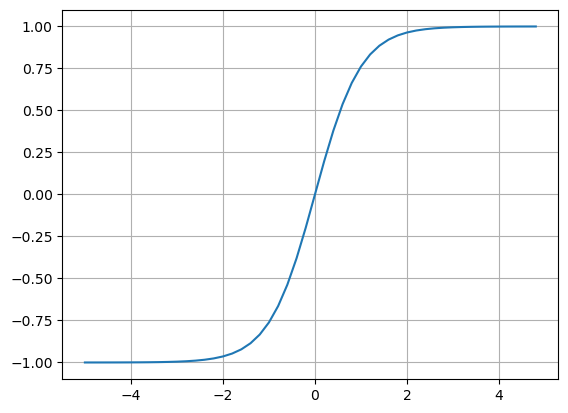

In [24]:
# This is the activation function
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid();

In [2]:
# inputs x1,x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# weights w1,w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias of the neuron
b = Value(6.8813735870195432, label="b")
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1*w1"
x2w2 = x2 * w2
x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "Σxi*wi"
n = x1w1x2w2 + b
n.label = "Σxi*wi + b"
o = n.tanh()
o.label = "o"

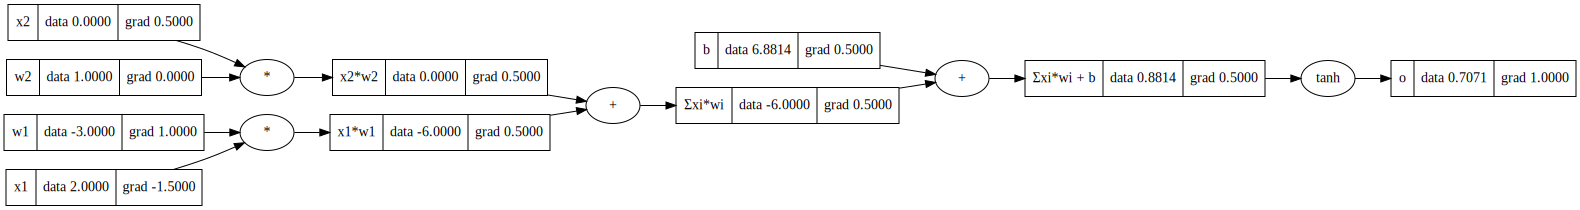

In [5]:
draw_dot(o)

MANUAL BACKPROP

In [33]:
o.grad = 1.0

In [34]:
# o = tanh(n)
# do/dn = 1 - o**2
1 - o.data**2

0.4999999999999999

In [35]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [36]:
# + distribute the grad
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
n.grad = 0.5

AUTOMATIC BACKPROP

In [56]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

FURTHER MORE AUTO DOING ALL THE BACKWARD

> here we have to run the _backward on child nodes and then parent
> this is achieved by topological sorting 

In [4]:
o.backward()